<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_WEEK13_1_KerasNLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **KerasNLP starter notebook Disaster Tweets**

- 트윗 문장을 보고 그 트윗이 실제 재난 상황을 말하는 트윗인지 아니면 비재난/일상 표현인지를 분류하는 모델을 만듦
- DistilBERT라는 사전학습 언어모델을 가져와서 재난 트윗 분류용으로 fine-tuning

1. 필요한 라이브러리 설치
2. 데이터 불러오기
3. 데이터 구조 확인
4. 트윗 길이 등 간단한 EDA
5. train / validation 데이터 분리
6. DistilBERT 모델 불러오기
7. 모델 fine-tuning 학습
8. confusion matrix로 성능 확인
9. test 데이터 예측
10. Kaggle 제출 파일 submission.csv 생성

In [1]:
!pip install keras-core --upgrade
!pip install -q keras-nlp --upgrade  # BERT, DistilBERT 같은 자연어처리 모델을 쉽게 불러와서 사용할 수 있게 해줌

import os
os.environ['KERAS_BACKEND'] = 'tensorflow'  # TensorFlow 기반 KerasNLP 코드

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_core as keras
import keras_nlp
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("KerasNLP version:", keras_nlp.__version__)

Using TensorFlow backend
TensorFlow version: 2.20.0
KerasNLP version: 0.29.0


## Load the Disaster Tweets

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df_train = pd.read_csv("/content/drive/MyDrive/ESAA/NLP/train (1).csv")
df_test = pd.read_csv("/content/drive/MyDrive/ESAA/NLP/test (1).csv")

print('Training Set Shape = {}'.format(df_train.shape))
print('Training Set Memory Usage = {:.2f} MB'.format(df_train.memory_usage().sum() / 1024**2))
print('Test Set Shape = {}'.format(df_test.shape))
print('Test Set Memory Usage = {:.2f} MB'.format(df_test.memory_usage().sum() / 1024**2))

Mounted at /content/drive
Training Set Shape = (7613, 5)
Training Set Memory Usage = 0.29 MB
Test Set Shape = (3263, 4)
Test Set Memory Usage = 0.10 MB


In [4]:
df_train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


- target = 1 → 실제 재난 트윗
- target = 0 → 재난이 아닌 트윗

In [5]:
df_test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


## Explore the dataset

In [6]:
df_train["length"] = df_train["text"].apply(lambda x : len(x))
df_test["length"] = df_test["text"].apply(lambda x : len(x))

print("Train Length Stat")
print(df_train["length"].describe())
print()

print("Test Length Stat")
print(df_test["length"].describe())

Train Length Stat
count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: length, dtype: float64

Test Length Stat
count    3263.000000
mean      102.108183
std        33.972158
min         5.000000
25%        78.000000
50%       109.000000
75%       134.000000
max       151.000000
Name: length, dtype: float64


## Preprocess the data

In [7]:
BATCH_SIZE = 32
NUM_TRAINING_EXAMPLES = df_train.shape[0]
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.2
STEPS_PER_EPOCH = int(NUM_TRAINING_EXAMPLES)*TRAIN_SPLIT // BATCH_SIZE

EPOCHS = 2
AUTO = tf.data.experimental.AUTOTUNE

In [8]:
from sklearn.model_selection import train_test_split

X = df_train["text"]
y = df_train["target"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VAL_SPLIT, random_state=42)

X_test = df_test["text"]

X_train → 학습용 트윗 문장

y_train → 학습용 정답

X_val → 검증용 트윗 문장

y_val → 검증용 정답

## Load a DistilBERT model from Keras NLP

- distil_bert_base_en_uncased
  - distil_bert → BERT를 가볍게 만든 모델
  - base → 기본 크기 모델
  - en → 영어 모델
  - uncased → 대소문자를 구분하지 않음

In [9]:
# DistilBERT 모델 불러오기
preset = "distil_bert_base_en_uncased"

# Preprocessor 설정
preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(preset, sequence_length=160,
                                                                   name="preprocessor_4_tweets")

# DistilBERT 분류 모델 생성
classifier = keras_nlp.models.DistilBertClassifier.from_preset(preset, preprocessor = preprocessor,
                                                               num_classes=2)

classifier.summary()

Preprocessor: "preprocessor_4_tweets"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,955,010 (255.41 MB)

 Trainable params: 66,955,010 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

## Train your own model, fine-tuning BERT

In [10]:
# Compile
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("현재 사용 device:", device)

classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),  # 손실함수 내부에서 softmax 처리
    # BERT 같은 사전학습 모델을 fine-tuning할 때는 이미 학습된 언어 지식을 너무 크게 망가뜨리면 안 되기 때문에
    # 학습률을 작게 잡음
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics= ["accuracy"]
)

# Fit
history = classifier.fit(x=X_train, y=y_train, batch_size=BATCH_SIZE, epochs=EPOCHS,
                         validation_data=(X_val, y_val))

현재 사용 device: cuda
Epoch 1/2
191/191 ━━━━━━━━━━━━━━━━━━━━ 170s 628ms/step - accuracy: 0.7683 - loss: 0.4919 - val_accuracy: 0.8359 - val_loss: 0.4015
Epoch 2/2
191/191 ━━━━━━━━━━━━━━━━━━━━ 106s 556ms/step - accuracy: 0.8488 - loss: 0.3683 - val_accuracy: 0.8424 - val_loss: 0.3875


In [11]:
# Confusion Matrix 함수
def displayConfusionMatrix(y_true, y_pred, dataset):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true,
        np.argmax(y_pred, axis=1),  # 각 행에서 가장 큰 값의 위치
        display_labels=["Not Disaster","Disaster"],
        cmap=plt.cm.Blues
    )

    tn, fp, fn, tp = confusion_matrix(y_true, np.argmax(y_pred, axis=1)).ravel()
    f1_score = tp / (tp+((fn+fp)/2))

    disp.ax_.set_title("Confusion Matrix on " + dataset + " Dataset -- F1 Score: " + str(f1_score.round(2)))

191/191 ━━━━━━━━━━━━━━━━━━━━ 45s 220ms/step


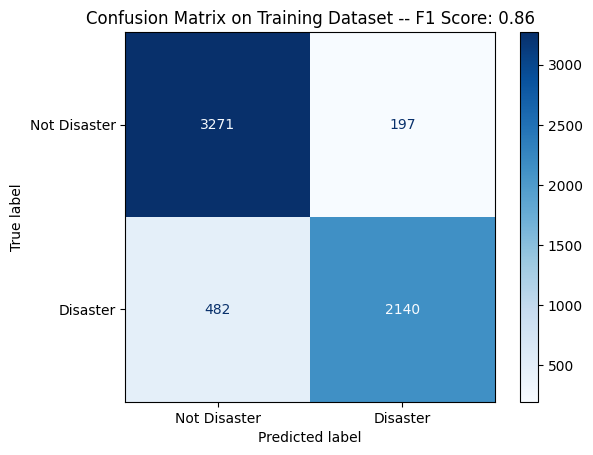

In [12]:
y_pred_train = classifier.predict(X_train)
# 모델이 학습에 직접 사용하지 않은 validation 데이터에 대해 얼마나 잘 맞히는지 확인
displayConfusionMatrix(y_train, y_pred_train, "Training")

48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 235ms/step


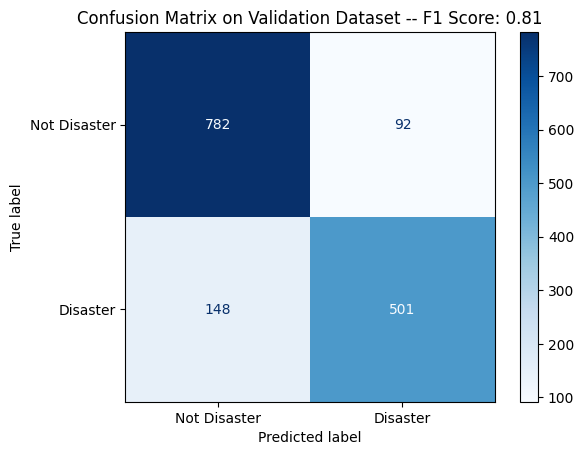

In [13]:
y_pred_val = classifier.predict(X_val)

displayConfusionMatrix(y_val, y_pred_val, "Validation")

- fine-tuning
  - 처음부터 트윗 분류 모델을 학습시키는 것이 아니라,
  - 이미 엄청난 양의 영어 텍스트로 학습된 DistilBERT를 가져와서,
  - 우리가 가진 재난 트윗 데이터에 맞게 살짝 다시 학습